## Deep Agents


In [1]:
## Basics Deep Agents
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [2]:
## Tools - Internet Search

from tavily import TavilyClient
from typing import Literal
tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

def web_search(query: str,max_results:int=5,topic: Literal["sports","news","finance"] = "general", include_raw_content:bool = False):
    """ Run a web search """
    return tavily_client.search(query,
    max_results=max_results,include_raw_content=include_raw_content,topic= topic)


In [3]:
from langchain.chat_models import init_chat_model

model = init_chat_model("groq:openai/gpt-oss-120b")
model

/Users/shivanshmishra2701gmail.com/Desktop/AgenticWorkspace/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x1174d5550>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1174d5fd0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

## Create a Basic Agent

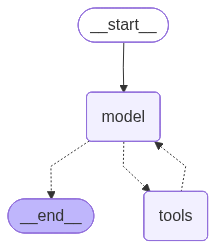

In [4]:
from langchain.agents import create_agent

simple_agent = create_agent(
    model = model,
    tools = [web_search]
)
simple_agent

## Create A Deep Agent

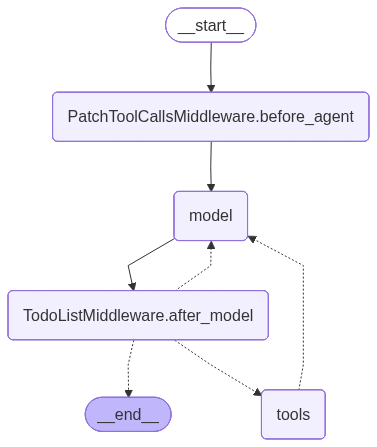

In [5]:
## Prompt


## Agent
from deepagents import create_deep_agent

deepagent = create_deep_agent(
    model = model,
    tools = [web_search],
    system_prompt= "Act as a researcher"
)
deepagent

In [7]:
result = deepagent.invoke({"messages":[{"role":"user","content":"What is deepagent"}]})
result

{'messages': [HumanMessage(content='What is deepagent', additional_kwargs={}, response_metadata={}, id='d973c1fb-2d05-4d80-b6be-d0a26f246c8d'),
  AIMessage(content='DeepAgent is a term used to describe an autonomous AI system that combines deep learning models with agentic capabilities. Such a system can:\n\n1. **Perceive** its environment (e.g., text, code, files, web data) using deep neural networks.\n2. **Reason and plan** by chaining together multiple actions, maintaining state, and selecting tools or sub‑agents to achieve goals.\n3. **Act** by invoking external tools (file I/O, web searches, subprocesses, etc.) or by generating outputs for a user.\n\nIn practice, a DeepAgent operates like a “thinking” assistant that can decompose complex tasks into sub‑tasks, execute them with appropriate tools, keep track of progress (e.g., with a todo list), and synthesize results into a final answer. It blends the pattern‑recognition power of deep learning with the procedural, goal‑directed beh